In [1]:
""" This script demonstrates how to calculate GT using the _wbgt.py script.
    Created by Riddhima Puri.
"""

import intake
import numpy as np
import xarray as xr
import pandas as pd

In [2]:
from xclim.indices._conversion import (
    _gather_lat,
    _gather_lon,
    solar_declination,
    cosine_of_solar_zenith_angle,
    _fdir_ratio
)

In [3]:
from _wbgt import Tg_10mwind

### Load Data

In [4]:
def load_dataset(files, var, t):

    ds = xr.open_mfdataset(files['path'], 
                            combine='by_coords', 
                            coords='minimal', 
                            compat='override',
                            parallel=True)[var]
    ds = ds.sel(time=t)
    # Rechunk the dataset
    ds = ds.chunk({'time': 8})
    return ds


#### Load data from intake catalog

We use the intake catalog to load EURO-CORDEX data. More information about this can be found on the dkrz website: https://tutorials.dkrz.de/Intake.html.
This data can be also be directly accessed from the Earth System Grid Federation system (ESGF; https://esgf-metagrid.cloud.dkrz.de/search/cordex-dkrz/).

In [5]:
experiment_id = 'historical'
rcm = 'GERICS-REMO2015'
driving_model = 'CCCma-CanESM2'
year = '2000'
month = '06'

In [6]:
# Load catalog
catalog = intake.open_esm_datastore("CORDEX.json")

# Search catalog
q_attrs = {
    'experiment_id': [experiment_id],
    'source_id': [rcm],
    'driving_model_id': [driving_model],
}

sub_cat = catalog.search(**q_attrs)

# Load dataset and filter by time range - files are stored monthly
df = sub_cat.df.query(f'time_range > "{year}-{month}-01" and time_range < "{str(int(year)+1)}-{month}-01"')  # filtering time range before loading

# Group datasets by variable
grouped_df = df.groupby('variable_id')
datasets = {}

# Extract datasets for each variable for one day
datasets = {var_name: load_dataset(files, var_name, f'{year}-{month}-01') for var_name, files in grouped_df}
# Extract variable names
variables = [var_name for var_name, files in grouped_df]


In [7]:
# Pre-processing

# Radiation variables are mean values and temperature, pressure, etc. are point values.
# Update time coordinate of all variables to match that of the point variables to avoid misalignment issues during computation
reference_time = datasets['tas'].time
for var in variables:
    if all(datasets[var].time != reference_time):
        datasets[var]["time"] = reference_time

# Reindex all datasets to match the lat-lon grid of 'tas' variable to avoid misalignment issues
for var in variables:
    datasets[var] = datasets[var].reindex_like(datasets['tas'], method = 'nearest')


### Calculate Globe Temperature

In [8]:
# Using xclim functions to calculate solar zenith angle and fdir

times = datasets['rsds'].time
dec = solar_declination(times)
lat = _gather_lat(datasets['rsds'])
lon = _gather_lon(datasets['rsds'])
# Cosine of solar zenith angle
cosza = cosine_of_solar_zenith_angle(times, dec, lat, lon, 
                                    stat="average", 
                                    sunlit=True,
                                    chunks=datasets['rsds'].chunksizes,
)
# change cosza=0 when the sun is below horizon to an arbitrary negative value (here we choose -0.5) to avoid division by zero 
cosza = xr.where(cosza <= 0, -0.5, cosza)

# ratio of direct solar radiation.
fdir = _fdir_ratio(times, cosza, datasets['rsds'])

In [9]:
cosza

<xarray.DataArray (time: 8, rlat: 412, rlon: 424)> Size: 11MB
dask.array<where, shape=(8, 412, 424), dtype=float64, chunksize=(8, 412, 424), chunktype=numpy.ndarray>
Coordinates:
    rotated_latitude_longitude  int32 4B 1
  * time                        (time) datetime64[ns] 64B 2000-06-01T01:00:00...
    height                      float64 8B 2.0
  * rlon                        (rlon) float64 3kB -28.38 -28.27 ... 18.04 18.16
  * rlat                        (rlat) float64 3kB -23.38 -23.27 ... 21.72 21.84

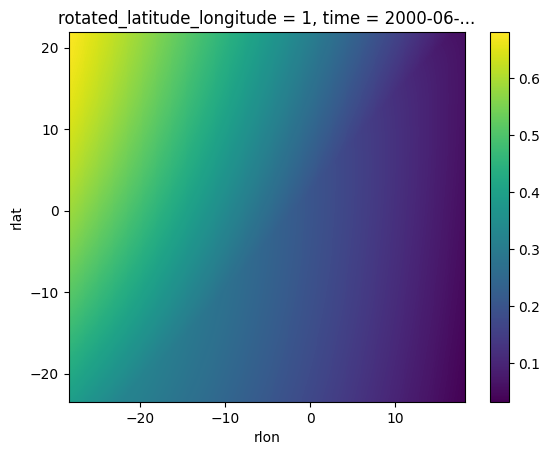

In [10]:
cosza[5,:,:].plot()

/work/ch0636/g300133/myenvs/lib/python3.10/site-packages/dask/_task_spec.py:741: RuntimeWarning: divide by zero encountered in reciprocal
  return self.func(*new_argspec)
/work/ch0636/g300133/myenvs/lib/python3.10/site-packages/dask/_task_spec.py:741: RuntimeWarning: overflow encountered in exp
  return self.func(*new_argspec)


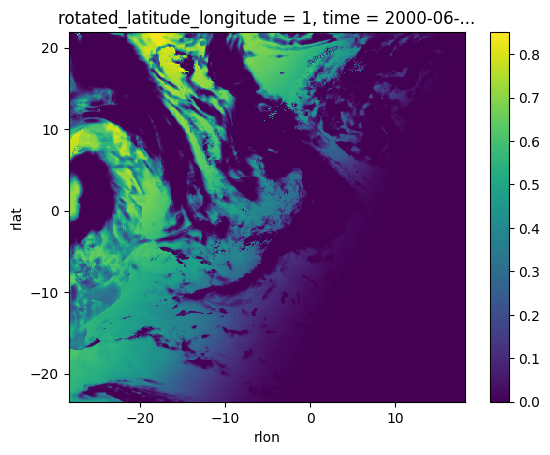

In [11]:
fdir[5,:,:].plot()

In [12]:
# Compute GT
gt = xr.apply_ufunc(Tg_10mwind, datasets['tas'], datasets['ps'], datasets['sfcWind'],
                    datasets['rsds'], datasets['rsus'], datasets['rlds'], datasets['rlus'], 
                    fdir, cosza, dask='parallelized', output_dtypes=[datasets['tas'].dtype])

/work/ch0636/g300133/myenvs/lib/python3.10/site-packages/dask/_task_spec.py:741: RuntimeWarning: divide by zero encountered in reciprocal
  return self.func(*new_argspec)
/work/ch0636/g300133/myenvs/lib/python3.10/site-packages/dask/_task_spec.py:741: RuntimeWarning: overflow encountered in exp
  return self.func(*new_argspec)


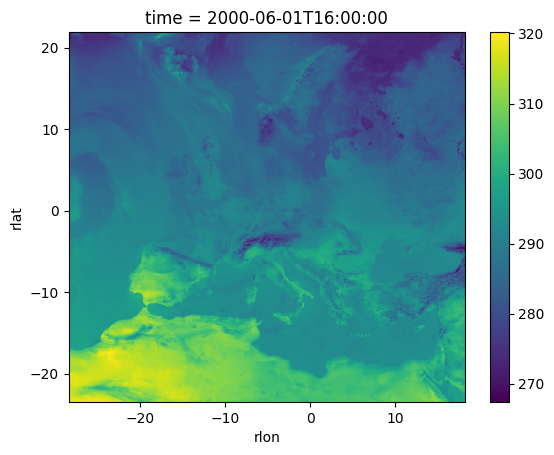

In [13]:
gt[5,:,:].plot()